In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/train (2).csv" , usecols=['Age', 'Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
X= df.drop(columns=['Survived'])
y =df['Survived']

In [6]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state=2)

In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [10]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [11]:
X_test.head()

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0


In [12]:
#so we are trying to fill the empty spcaes with other value of age
#this code will provide us all the empty spces in age
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

,Age_imputed
77,NaN
868,NaN
334,NaN
295,NaN
792,NaN
...,...
674,NaN
466,NaN
584,NaN
527,NaN


In [14]:
#X_train['Age_imputed'][X_train['Age_imputed'].isnull()] - this part of the code will give u all the null values
#X_train['Age'].dropna() - this code will drop all the null values from the X_tain
#.sample(X_train['Age'].isnull().sum()) - gives u the sample values from the not null part of the training set
#(X_train['Age'].isnull().sum()) - this part inside the sample defines the number of missing values - meaning the number of sample values we need

X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipython-input-1230531893.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipython-input-1230531893.py

In [15]:
#the right hand side code -
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([42.  , 22.  , 22.  , 31.  , 28.  , 45.  , 31.  , 26.  , 40.  ,
       18.  , 33.  , 31.  , 46.  , 39.  , 19.  , 45.  , 24.  , 44.  ,
       50.  , 30.  ,  8.  , 29.  , 45.  , 39.  , 28.  , 61.  , 58.  ,
       45.  , 24.  ,  2.  , 17.  ,  2.  ,  0.42, 27.  , 35.  , 25.  ,
       13.  , 25.  , 14.  , 54.  , 23.  , 19.  , 40.  , 26.  , 36.  ,
        3.  , 37.  , 56.  , 24.  , 16.  , 24.  , 21.  , 31.  , 16.  ,
       34.  , 26.  , 25.  , 16.  , 35.  , 18.  ,  9.  , 41.  , 58.  ,
       36.  ,  4.  , 47.  , 22.  , 32.  , 22.  , 15.  , 29.  , 59.  ,
       26.  , 35.  , 50.  , 29.  , 28.5 ,  2.  , 28.  , 35.  , 50.  ,
       45.  , 32.  , 30.  , 47.  , 34.  , 36.  , 18.  , 51.  , 19.  ,
       28.5 , 33.  , 65.  , 45.  , 39.  ,  4.  ,  3.  , 17.  , 50.  ,
       23.  , 39.  , 48.  , 41.  , 16.  , 61.  , 27.  ,  1.  , 27.  ,
       19.  , 30.  , 35.  , 36.  , 25.  , 51.  , 22.  , 30.  , 14.  ,
        8.  , 16.  , 33.  , 58.  , 59.  , 24.  , 35.  , 30.5 , 17.  ,
       11.  , 45.  ,

In [16]:
#number of missing values or the number of values which needs to be filled using the trainig set
X_train['Age'].isnull().sum()

np.int64(148)

In [17]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,16.0
493,71.0,49.5042,71.0
527,NaN,221.7792,27.0


/tmp/ipython-input-1497453626.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'], label = 'Original' , hist = False)
/tmp/ipython-input-1497453626.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'] , label = 'Imputed' , hist = False)


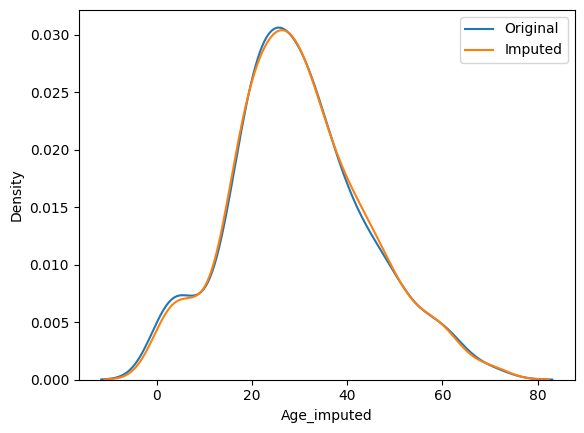

In [20]:
#checking the distribution
sns.distplot(X_train['Age'], label = 'Original' , hist = False)
sns.distplot(X_train['Age_imputed'] , label = 'Imputed' , hist = False)

plt.legend()
plt.show()

In [21]:
#checking the variance
print('orignal variance ' , X_train['Age'].var())
print('variance after being imputed ' , X_train['Age_imputed'].var())

orignal variance  204.3495133904614
variance after being imputed  201.0669774820636


In [22]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.372694
Age,71.512440,204.349513,204.349513
Age_imputed,57.372694,204.349513,201.066977


<Axes: >

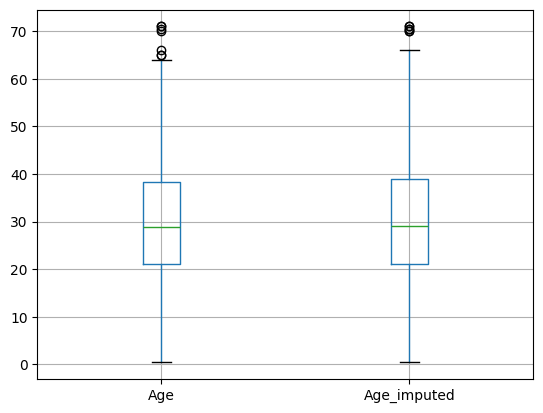

In [23]:
X_train[['Age' , 'Age_imputed']].boxplot()

In [27]:
# For production: generate the same sampled value for a given input every time
sampled_value = X_train['Age'].dropna().sample(n=1, random_state=42).iloc[0]



In [28]:
data = pd.read_csv('/content/house-train.csv' , usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [29]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [30]:
data.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


In [32]:
X = data
y = data['SalePrice']

In [34]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [35]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu-imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu-imputed'] = X_test['FireplaceQu']


In [36]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu-imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [38]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu-imputed'][X_train['FireplaceQu-imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu-imputed'][X_test['FireplaceQu-imputed'].isnull()] = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipython-input-3918181154.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp

In [44]:
temp = pd.concat([
    X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts()/len(X_train)
], axis = 1)

temp.columns=['Original' , 'imputed']

In [42]:
temp1 = pd.concat([
    X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu-imputed'].value_counts()/len(X_train)
], axis = 1)

temp.columns=['Original' , 'imputed']

In [43]:
temp1

,count,count
Gd,0.494272,0.494007
TA,0.412439,0.413527
Fa,0.040917,0.041096
Po,0.027823,0.028253
Ex,0.024550,0.023116


In [45]:
temp

,Original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.035959
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


/tmp/ipython-input-977173224.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu']== category]['SalePrice' ], hist = False , label=category)
/tmp/ipython-input-977173224.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQ

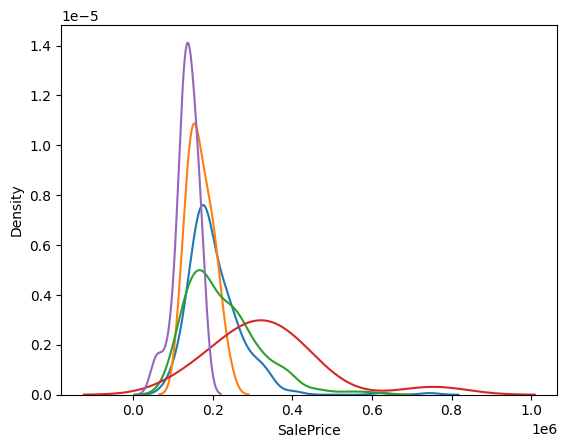

In [46]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu']== category]['SalePrice' ], hist = False , label=category)
plt.show()

/tmp/ipython-input-444096943.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu-imputed']== category]['SalePrice' ], hist = False , label=category)
/tmp/ipython-input-444096943.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Fi

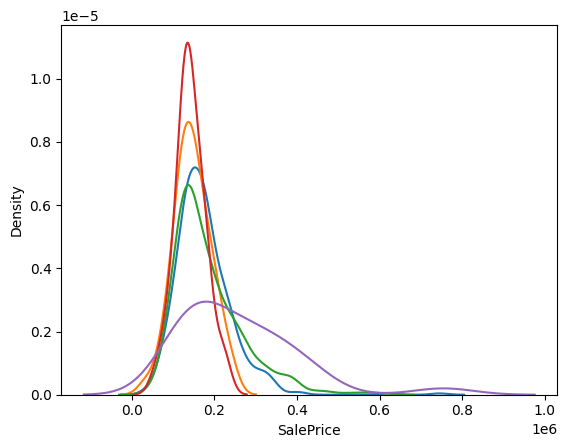

In [47]:
for category in X_train['FireplaceQu-imputed'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu-imputed']== category]['SalePrice' ], hist = False , label=category)
plt.show()